findfont: Failed to find font weight bold, now using 400.


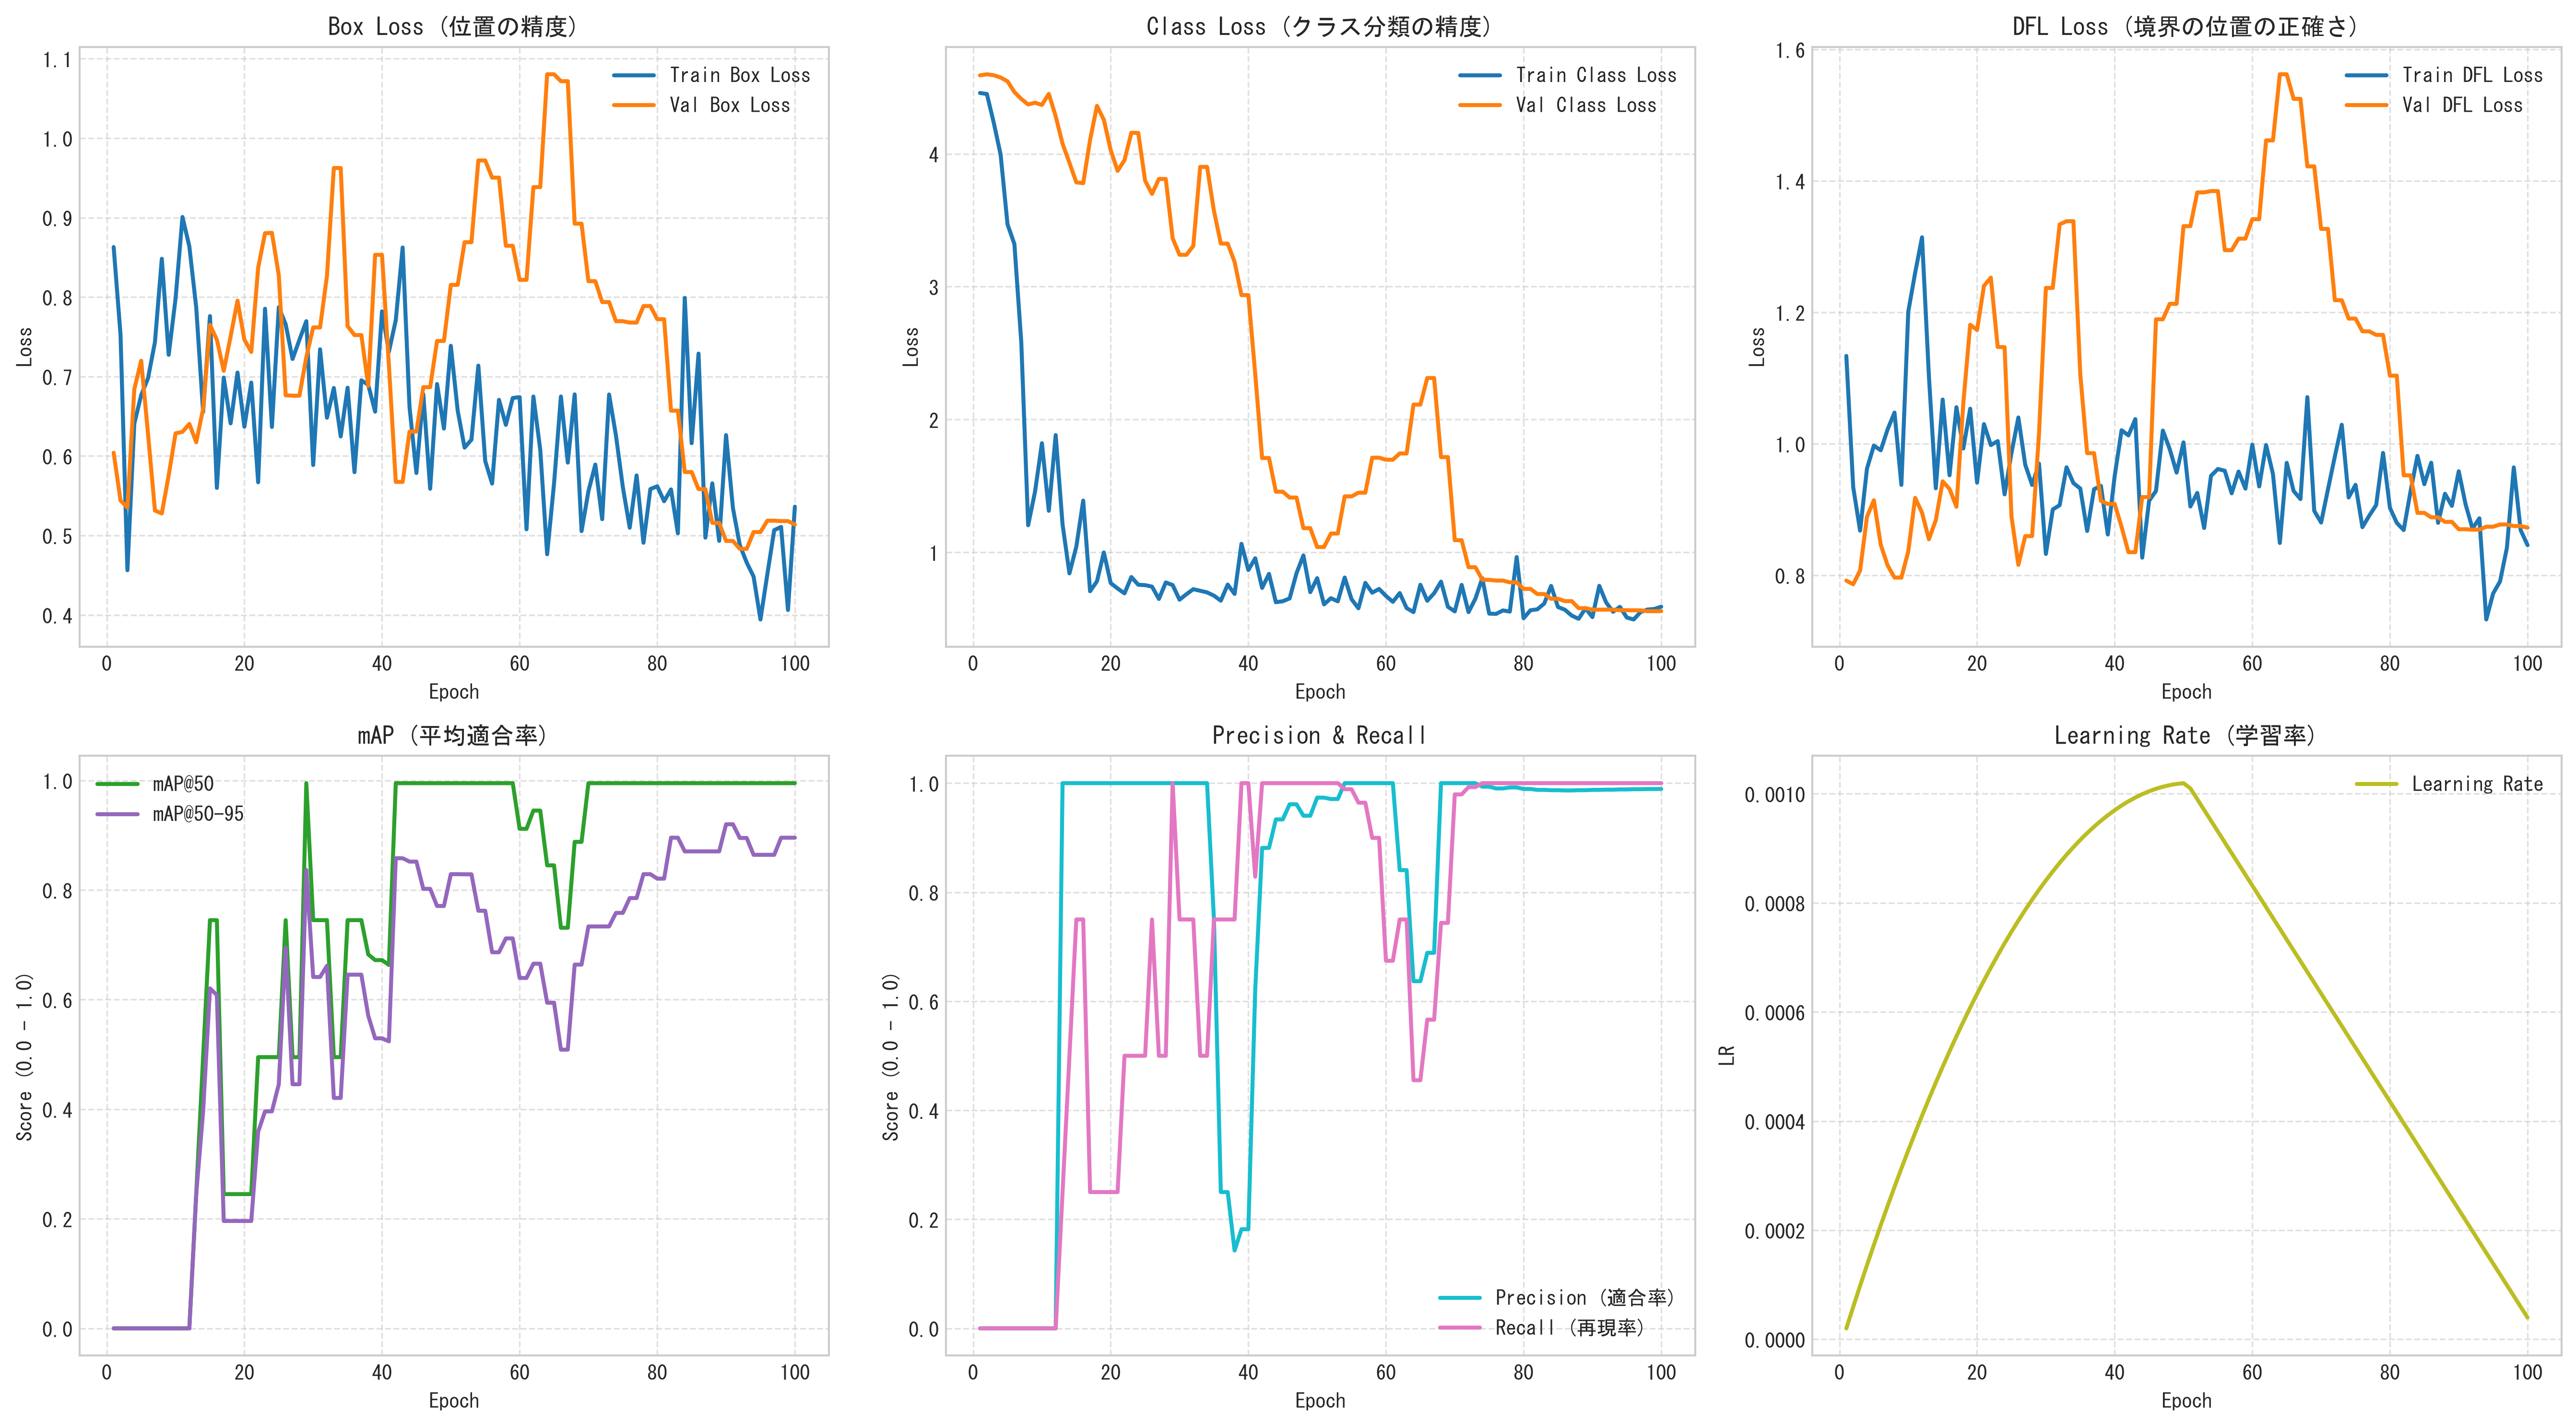

In [ ]:
#カスタムグラフ表示用
import pandas as pd
import matplotlib.pyplot as plt


csv_path = r"C:\YOLO\YOLO\runs\detect\train-6\results.csv" 
df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()

#グラフのデザイン設定
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'MS Gothic'

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)

# Box Loss
axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='#1f77b4', linewidth=2)
axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='#ff7f0e', linewidth=2)
axes[0, 0].set_title('Box Loss (位置の精度)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

#Class Loss
axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', color='#1f77b4', linewidth=2)
axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Class Loss', color='#ff7f0e', linewidth=2)
axes[0, 1].set_title('Class Loss (クラス分類の精度)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# DFL Loss
axes[0, 2].plot(df['epoch'], df['train/dfl_loss'], label='Train DFL Loss', color='#1f77b4', linewidth=2)
axes[0, 2].plot(df['epoch'], df['val/dfl_loss'], label='Val DFL Loss', color='#ff7f0e', linewidth=2)
axes[0, 2].set_title('DFL Loss (境界の位置の正確さ)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].grid(True, linestyle='--', alpha=0.6)

# mAP 
axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='#2ca02c', linewidth=2)
axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='#9467bd', linewidth=2)
axes[1, 0].set_title('mAP (平均適合率)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score (0.0 - 1.0)')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

#Precision,Recall
axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision (適合率)', color='#17becf', linewidth=2)
axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall (再現率)', color='#e377c2', linewidth=2)
axes[1, 1].set_title('Precision & Recall', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score (0.0 - 1.0)')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

#Learning Rate
if 'lr/pg0' in df.columns:
    axes[1, 2].plot(df['epoch'], df['lr/pg0'], label='Learning Rate', color='#bcbd22', linewidth=2)
axes[1, 2].set_title('Learning Rate (学習率)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('LR')
axes[1, 2].legend()
axes[1, 2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
save_path = r"C:\YOLO\YOLO\runs\detect\train-6\custom_results.png"
plt.savefig(save_path, bbox_inches='tight')
plt.show()